In [1]:
!pip install pandas matplotlib seaborn opencv-python pillow tqdm

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 9.5 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 9.5 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 10.0 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contou

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
altair 5.1.2 requires jsonschema>=3.0, which is not installed.
altair 5.1.2 requires toolz, which is not installed.
gradio 3.47.1 requires huggingface-hub>=0.14.0, which is not installed.
gradio 3.47.1 requires markupsafe~=2.0, but you have markupsafe 3.0.2 which is incompatible.
gradio 3.47.1 requires numpy~=1.0, but you have numpy 2.0.1 which is incompatible.
gradio 3.47.1 requires pillow<11.0,>=8.0, but you have pillow 11.1.0 which is incompatible.
gradio 3.47.1 requires websockets<12.0,>=10.0, but you have websockets 16.0 which is incompatible.


In [9]:
import os

plantvillage_path = r"C:\Education\Research\Datasets\PlantVillage"

classes = os.listdir(plantvillage_path)

print("Number of Classes:", len(classes))
print(classes[:10])

Number of Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold']


In [24]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [10]:
import os
import pandas as pd

data = []

for cls in os.listdir(plantvillage_path):
    cls_path = os.path.join(plantvillage_path, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        data.append([cls, count])

df = pd.DataFrame(data, columns=["Class", "Images"])
df.sort_values("Images", ascending=False)

,Class,Images
14,Tomato__Tomato_YellowLeaf__Curl_Virus,3209
5,Tomato_Bacterial_spot,2127
8,Tomato_Late_blight,1909
10,Tomato_Septoria_leaf_spot,1771
11,Tomato_Spider_mites_Two_spotted_spider_mite,1676
7,Tomato_healthy,1591
1,Pepper__bell___healthy,1478
12,Tomato__Target_Spot,1404
2,Potato___Early_blight,1000
4,Potato___Late_blight,1000


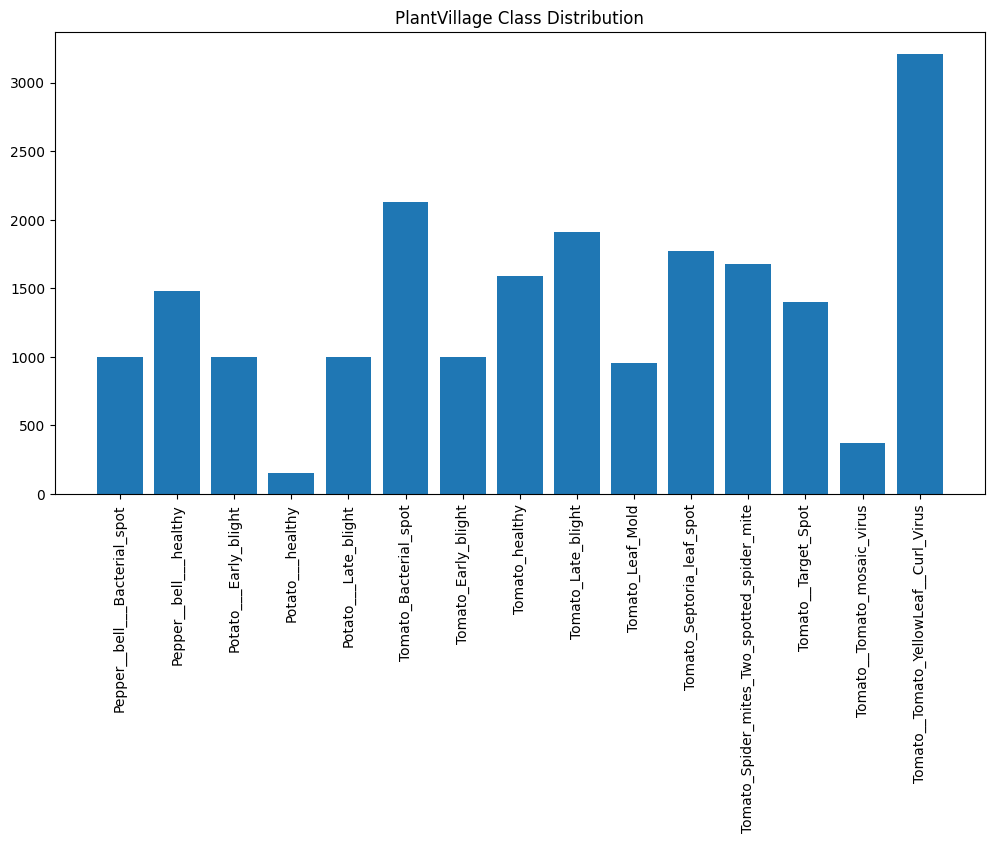

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df["Class"], df["Images"])
plt.xticks(rotation=90)
plt.title("PlantVillage Class Distribution")
plt.show()

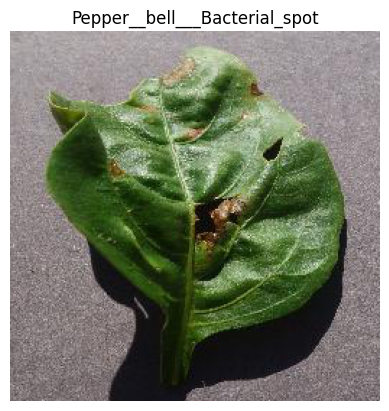

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_class = os.listdir(plantvillage_path)[0]

sample_folder = os.path.join(plantvillage_path, sample_class)

sample_image = random.choice(os.listdir(sample_folder))

img = Image.open(os.path.join(sample_folder, sample_image))

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [13]:
from PIL import Image
import os

sizes = []

for cls in os.listdir(plantvillage_path):
    cls_path = os.path.join(plantvillage_path, cls)

    if os.path.isdir(cls_path):
        img_file = os.listdir(cls_path)[0]

        img = Image.open(os.path.join(cls_path, img_file))

        sizes.append(img.size)

print(set(sizes))

{(256, 256)}


In [14]:
import os

dataset_path = plantvillage_path

total_images = 0
num_classes = 0

for cls in os.listdir(dataset_path):

    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):

        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg','.jpeg','.png'))
        ])

        print(f"{cls}: {count}")

        total_images += count
        num_classes += 1

print("\nTotal Classes:", num_classes)
print("Total Images:", total_images)

Pepper__bell___Bacterial_spot: 997
Pepper__bell___healthy: 1478
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_healthy: 1591
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_mosaic_virus: 373
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208

Total Classes: 15
Total Images: 20638


In [16]:
import torch

print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0).total_memory/1024**3)

NVIDIA GeForce GTX 1650
3.99969482421875


# Mobile_Net

In [17]:
!pip install timm torchmetrics

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   -------------------------------- ------- 2.1/2.6 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 10.0 MB/s  0:00:00
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------------------------------------- 983.4/983.4 kB 9.1 MB/s  0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   --------------- ------------------------ 2.4/6.2 MB 12.2 MB/s eta 0:00:01
   --------------------------- ------------ 4.2/6.2 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 6.2/6.2 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/784.9 kB ? eta -:--:--
   ---------------------------------------- 784.9/784.9 kB 8.3 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -------------------- ------------------- 2.1/4.0 MB 10.7 MB/s eta 0:00:01
   --------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 3.47.1 requires markupsafe~=2.0, but you have markupsafe 3.0.2 which is incompatible.
gradio 3.47.1 requires numpy~=1.0, but you have numpy 2.0.1 which is incompatible.
gradio 3.47.1 requires pillow<11.0,>=8.0, but you have pillow 11.1.0 which is incompatible.
gradio 3.47.1 requires websockets<12.0,>=10.0, but you have websockets 16.0 which is incompatible.
gradio-client 0.6.0 requires websockets<12.0,>=10.0, but you have websockets 16.0 which is incompatible.


In [18]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.models import mobilenet_v3_small

In [19]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [20]:
dataset_path = r"C:\Education\Research\Datasets\PlantVillage"

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Classes:", len(dataset.classes))
print("Images:", len(dataset))

Classes: 15
Images: 20638


In [21]:
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [22]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

In [25]:
model = mobilenet_v3_small(weights="DEFAULT")

num_classes = len(dataset.classes)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    num_classes
)

model = model.to(device)

In [26]:
params = sum(p.numel() for p in model.parameters())

print(f"Parameters: {params:,}")

Parameters: 1,533,231


In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [28]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [29]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(loader)

    val_acc = 100 * correct / total

    return val_loss, val_acc

In [30]:
num_epochs = 10

In [31]:
for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] Train Loss: 0.2823 Train Acc: 90.77% Val Loss: 0.3234 Val Acc: 90.11%
Epoch [2/10] Train Loss: 0.0876 Train Acc: 97.18% Val Loss: 0.1797 Val Acc: 94.45%
Epoch [3/10] Train Loss: 0.0690 Train Acc: 97.82% Val Loss: 0.3270 Val Acc: 92.25%
Epoch [4/10] Train Loss: 0.0484 Train Acc: 98.57% Val Loss: 0.0616 Val Acc: 98.06%
Epoch [5/10] Train Loss: 0.0470 Train Acc: 98.64% Val Loss: 0.0830 Val Acc: 97.53%
Epoch [6/10] Train Loss: 0.0470 Train Acc: 98.53% Val Loss: 0.0627 Val Acc: 97.87%
Epoch [7/10] Train Loss: 0.0351 Train Acc: 98.98% Val Loss: 0.1336 Val Acc: 96.10%
Epoch [8/10] Train Loss: 0.0463 Train Acc: 98.64% Val Loss: 0.1900 Val Acc: 95.37%
Epoch [9/10] Train Loss: 0.0465 Train Acc: 98.58% Val Loss: 0.3022 Val Acc: 92.54%
Epoch [10/10] Train Loss: 0.0290 Train Acc: 99.07% Val Loss: 0.1394 Val Acc: 96.54%


In [32]:
best_acc = 0

if val_acc > best_acc:
    best_acc = val_acc
    torch.save(model.state_dict(),
               "best_mobilenetv3.pth")

In [33]:
params = sum(p.numel() for p in model.parameters())

print(f"Parameters: {params:,}")

Parameters: 1,533,231


In [34]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []
train_losses.append(train_loss)
val_losses.append(val_loss)

train_accs.append(train_acc)
val_accs.append(val_acc)

In [35]:
train_losses

[0.02901287592926283]

In [36]:
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

In [38]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

In [39]:
from sklearn.metrics import accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", acc*100)

Test Accuracy: 97.046004842615


In [41]:
import os

size_mb = os.path.getsize(r"C:\Education\Research\best_mobilenetv3.pth") / (1024*1024)

print(f"Model Size: {size_mb:.2f} MB")

Model Size: 5.98 MB


In [42]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [43]:
precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

In [46]:
print(precision)
print(recall)
print(f1)

0.9731307548815084
0.9704600484261501
0.9702830028231381


In [47]:
import time

model.eval()

start = time.time()

with torch.no_grad():
    output = model(images[:1])

end = time.time()

print((end-start)*1000, "ms")

30.756711959838867 ms


In [48]:
!pip install ptflops

In [49]:
from ptflops import get_model_complexity_info

macs, params = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=True,
    print_per_layer_stat=False
)

print("MACs:", macs)
print("Params:", params)

C:\Users\varik\anaconda3\envs\torch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MACs: 59.9 MMac
Params: 1.53 M
